In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from processing import (
    DATA_DIRECTORY,
    preprocess_raw_data,
    read_preprocessed_csv,
)
from read_configuration import (
    EXPERIMENT_CONFIGS_PATH,
    load_experiment_configs_from_ids,
)

sns.set_context("notebook") # makes the text in the plots larger, for better visibility
%config InlineBackend.figure_format = 'svg' # makes the plots HD in the notebook
mpl.rcParams["figure.autolayout"] = True # enables tigh layout. Better multiplots
plt.rcParams['font.family'] = 'sans-serif'

/Users/montis/workspace/workarena_hackathon/AgentLab/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
ids = ["hpa_planner_gemini-3-flash_actor_gpt-5_59.6"]

In [4]:
experiment_configs = load_experiment_configs_from_ids(ids=ids, config_path=EXPERIMENT_CONFIGS_PATH)

In [5]:
preprocessed_df_list = []

for experiment_config in experiment_configs:
    if (DATA_DIRECTORY / f"preprocessed_{experiment_config.subset}_{experiment_config.id}.csv").exists():
        preprocessed_df_list.append(read_preprocessed_csv(path=DATA_DIRECTORY / f"preprocessed_{experiment_config.subset}_{experiment_config.id}.csv"))
    else:
        preprocessed_df_list.append(preprocess_raw_data(experiment_config=experiment_config))

In [6]:
preprocessed_df = pd.concat(preprocessed_df_list).reset_index(drop=True)

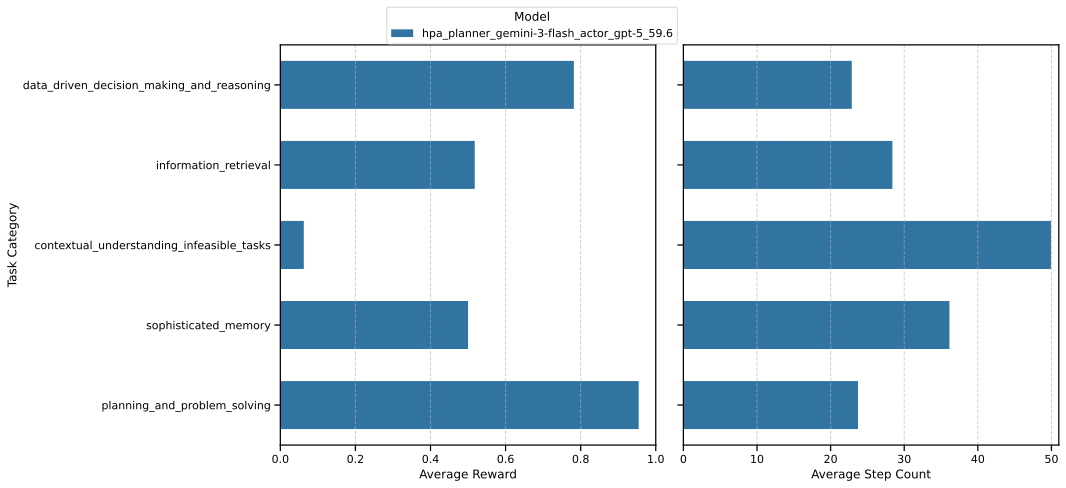

In [7]:
def plot_combined_reward_step_count(df: pd.DataFrame, save: bool = False):
    # 1. Increase figsize height to accommodate thicker bars
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7), sharey=True)
    sorted_df = df.sort_values(by=["model", "cum_reward"], ascending=[False, True])

    # Plotting parameters
    # width: total space used by the group (0.8 is standard, 0.9 is chunky)
    # gap: space between the bars within the group (0.1 - 0.2 is usually ideal)
    plot_params = {
        "data": sorted_df,
        "y": "task_category",
        "hue": "model",
        "orient": 'h',
        "errorbar": None,
        "width": 0.6,    
    }

    # Left Plot: Average Reward
    sns.barplot(ax=ax1, x="cum_reward", **plot_params)
    ax1.set_xlabel("Average Reward")
    ax1.set_ylabel("Task Category")
    ax1.grid(True, axis="x", linestyle="--", alpha=0.6)
    ax1.set_xlim(0, 1)

    # Right Plot: Average Step Count
    sns.barplot(ax=ax2, x="n_steps", **plot_params)
    ax2.set_xlabel("Average Step Count")
    ax2.set_ylabel("") 
    ax2.grid(True, axis="x", linestyle="--", alpha=0.6)
    ax2.set_xlim(0, 51)

    # Legend & Layout
    handles, labels = ax1.get_legend_handles_labels()
    ax1.get_legend().remove()
    ax2.get_legend().remove()
    fig.legend(handles, labels, loc='upper center', title="Model", 
               bbox_to_anchor=(0.5, 0.98), ncol=len(labels))

    # Optional: Increase space between the subplots
    plt.subplots_adjust(wspace=0.15) 
    plt.tight_layout(rect=[0, 0, 1, 0.92])

    if save:
        models_str = '_'.join(df.model.unique())
        plt.savefig(f"plots/l2_combined_metrics_{models_str}.png", bbox_inches="tight", dpi=200)
    
    plt.show()

plot_combined_reward_step_count(preprocessed_df)

In [8]:
preprocessed_df["env.task_seed"].unique()

array([121, 102, 435, 106, 700, 860,  20, 614, 270,  71, 661, 663, 308,
       130,  99, 466, 871, 330,  87, 458, 214, 372])

<Axes: xlabel='env.task_seed', ylabel='Count'>

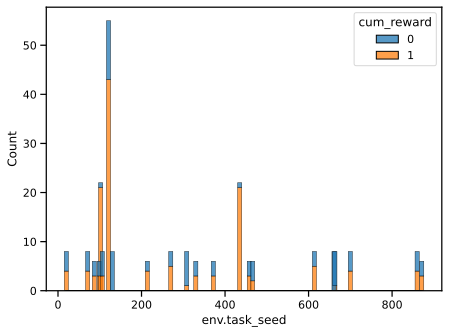

In [9]:
sns.histplot(preprocessed_df, x="env.task_seed", hue="cum_reward", multiple="stack", discrete=True, shrink=10)

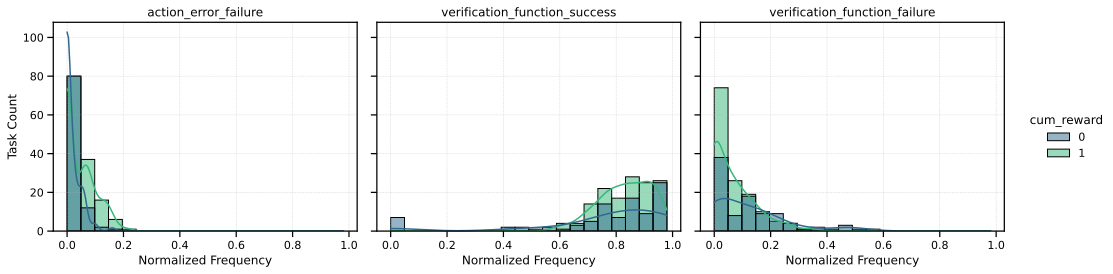

In [10]:
# 1. Expand the dictionaries into a DataFrame
df_stats = pd.DataFrame(preprocessed_df['action_verifications'].tolist())
df_stats = df_stats.drop(columns=['action_error_success', 'no_verification', 'first_step'])

# 2. Add the cum_reward column to this new DataFrame
# We use .values to ensure alignment if indices have been reset
df_stats['cum_reward'] = preprocessed_df['cum_reward'].values

# 3. Melt the data, but keep 'cum_reward' as an identifier variable
df_melted = df_stats.melt(
    id_vars=['cum_reward'], 
    var_name='Verification Type', 
    value_name='Value'
)

# 4. Plot with hue="cum_reward"
g = sns.displot(
    data=df_melted, 
    x="Value", 
    hue="cum_reward",   # This creates the color grouping
    col="Verification Type", 
    col_wrap=3,
    kind="hist",         # Using KDE for clearer overlapping distributions
    kde=True,
    fill=True,          # Fills the area under the curve
    common_norm=False,  # Normalizes each hue group independently
    palette="viridis",  # Aesthetic color map
    facet_kws={'sharey': True},
    height=4, 
    aspect=1.2,
    bins=20,
)

# Cleanup
g.set_titles("{col_name}")
g.set_axis_labels("Normalized Frequency", "Task Count")
plt.subplots_adjust(top=0.9)
# g.fig.suptitle('Action Verification Distributions by Cumulative Reward')

for ax in g.axes.flat:
    ax.grid(True, alpha=0.5, linestyle='--', linewidth=0.5)
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    
plt.show()

In [11]:
# mask = [sum(action_verifications.values()) == 0 for action_verifications in preprocessed_hpa["action_verifications"]]
# preprocessed_hpa[mask]

In [12]:
# preprocessed_hpa["err_msg"].dropna()

In [13]:
# import rich

# rich.print(preprocessed_hpa["tree_evolution"].iloc[0])

In [14]:
# aggregated_df_list = [aggregate_by_task_name_and_compute_statistics(df=preprocessed_df, )]